# ECG trace reconstruction

Explore three approaches to reconnecting fragmented ECG image traces: connected components, slope-aware row processing, and endpoint debugging.

The included demonstration uses `result/example.png`, a **binary crop with white foreground on black**. Outputs are image masks and visual diagnostics. This notebook does not yet export calibrated time–voltage samples.

Run all cells from the repository root. Generated files go to `outputs/signal-fixing/`; the original sample is kept intact.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import math
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

ROOT = Path.cwd()
INPUT_IMAGE = ROOT / "result" / "example.png"
OUTPUT_DIR = ROOT / "outputs" / "signal-fixing"
if not INPUT_IMAGE.exists():
    raise FileNotFoundError("Start Jupyter from the repository root so result/example.png is available.")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Input: {INPUT_IMAGE.relative_to(ROOT)}")
print(f"Outputs: {OUTPUT_DIR.relative_to(ROOT)}")

Input: result/example.png
Outputs: outputs/signal-fixing


## 1. Component-distance baseline

Skeletonize the binary image, find disconnected components, and bridge component pairs whose nearest pixels fall within a distance threshold. Newly added bridge pixels are dilated before merging with the input.

This baseline makes the geometry easy to inspect; a short distance alone does not establish that two segments belong to the same trace.

In [2]:
import cv2
import numpy as np
import math
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops


def fix_ecg_by_components(
    image: np.ndarray,
    distance_threshold: float = 30
) -> (np.ndarray, int):
    """
    Skeletonizes the ECG, identifies disconnected parts,
    and connects them using thin lines.
    """
    skel_bool = skeletonize(image == 255)
    skeleton = (skel_bool * 255).astype(np.uint8)

    labeled = label(skel_bool, connectivity=2)
    props = regionprops(labeled)
    if len(props) < 2:
        return skeleton, 0

    region_coords = [p.coords for p in props]

    def min_distance_between(coords1, coords2):
        min_dist = float('inf')
        closest_pair = None
        for (r1, c1) in coords1:
            for (r2, c2) in coords2:
                dist_sq = (r2 - r1) ** 2 + (c2 - c1) ** 2
                if dist_sq < min_dist:
                    min_dist = dist_sq
                    closest_pair = ((r1, c1), (r2, c2))
        return math.sqrt(min_dist), closest_pair

    connections = 0
    for i in range(len(props)):
        for j in range(i + 1, len(props)):
            dist, pair = min_distance_between(region_coords[i], region_coords[j])
            if dist < distance_threshold:
                (r1, c1), (r2, c2) = pair
                cv2.line(skeleton, (c1, r1), (c2, r2), 255, 1)
                connections += 1

    return skeleton, connections


def estimate_ecg_thickness(image: np.ndarray) -> int:
    """
    Estimate average ECG line thickness.
    """
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 5

    thicknesses = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        thicknesses.append(max(min(w, h), 1))

    return max(int(np.median(thicknesses)), 2)


def iterative_component_bridging(
    image_path: str,
    invert: bool = False,
    max_iterations: int = 5,
    distance_threshold: float = 30,
    dilation_kernel_size: int = None
) -> np.ndarray:
    """
    Iteratively skeletonizes and connects disconnected ECG segments,
    dilating only the new bridges to preserve original detail.
    """
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        raise ValueError(f"Could not read image: {image_path}")

    if invert:
        img_gray = 255 - img_gray

    _, bin_img = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
    current_img = bin_img.copy()

    if dilation_kernel_size is None:
        dilation_kernel_size = estimate_ecg_thickness(current_img)
        print(f"🧠 Estimated ECG thickness: {dilation_kernel_size} pixels")

    for iteration in range(max_iterations):
        skeleton, connections = fix_ecg_by_components(current_img, distance_threshold)

        if connections == 0:
            print(f"[Iteration {iteration + 1}] No new connections. Stopping.")
            break

        print(f"[Iteration {iteration + 1}] Connected {connections} new lines.")

        # ✅ Isolate only the new bridge segments
        bridge_mask = cv2.bitwise_and(skeleton, cv2.bitwise_not(current_img))

        # ✅ Dilate only the bridge segments
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (dilation_kernel_size, dilation_kernel_size)
        )
        bridge_dilated = cv2.dilate(bridge_mask, kernel, iterations=1)

        # ✅ Merge bridges with original without overwriting
        bridged_img = cv2.bitwise_or(current_img, bridge_dilated)
        current_img = bridged_img

    return current_img


if __name__ == "__main__":
    input_path = str(INPUT_IMAGE)  # 🔁 Replace with your ECG image
    output_path = str(OUTPUT_DIR / "component-bridged.png")

    final_img = iterative_component_bridging(
        image_path=input_path,
        invert=False,
        max_iterations=5,
        distance_threshold=48,
        dilation_kernel_size=None  # Automatically estimate
    )

    cv2.imwrite(output_path, final_img)
    print(f"✅ Done. Bridged ECG saved to: {Path(output_path).relative_to(ROOT)}")


🧠 Estimated ECG thickness: 33 pixels


[Iteration 1] Connected 10 new lines.
[Iteration 2] No new connections. Stopping.
✅ Done. Bridged ECG saved to: outputs/signal-fixing/component-bridged.png


## 2. Row-wise processing with geometric constraints

Split the image at blank horizontal rows, close small breaks, then score candidate endpoint pairs using distance and local slope. Vertical displacement and skeleton-intersection checks further restrict candidate bridges.

The loop stops when a pass forms no new connections. Its parameters are pixel-scale heuristics, so changing image resolution changes their interpretation.

In [3]:
import cv2
import numpy as np
import math
from skimage.morphology import skeletonize, closing
from skimage.measure import label, regionprops

##############################################################################
# Row Segmentation
##############################################################################

def segment_ecg_into_rows(bin_img: np.ndarray, row_height_threshold: int = 20) -> list:
    """
    Splits a binary ECG image (white=255 on black=0) into horizontal 'rows' or leads.
    Looks for horizontal blank spaces to segment rows.
    
    Returns a list of (top, bottom, sub_img).
    """
    row_sums = np.sum(bin_img == 255, axis=1)
    h, w = bin_img.shape
    
    rows = []
    in_row = False
    row_start = 0
    
    for y in range(h):
        if row_sums[y] > 0 and not in_row:
            row_start = y
            in_row = True
        elif row_sums[y] == 0 and in_row:
            row_end = y
            if (row_end - row_start) >= row_height_threshold:
                sub_img = bin_img[row_start:row_end, :]
                rows.append((row_start, row_end, sub_img))
            in_row = False

    # If the ECG extends to the bottom
    if in_row:
        row_end = h
        if (row_end - row_start) >= row_height_threshold:
            sub_img = bin_img[row_start:row_end, :]
            rows.append((row_start, row_end, sub_img))

    return rows

##############################################################################
# Morphological Closing
##############################################################################

def apply_small_morphological_closing(bin_img: np.ndarray, kernel_size=(3,3)) -> np.ndarray:
    """
    Applies a small morphological closing to fix tiny holes or breaks.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    closed = cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, kernel)
    return closed

##############################################################################
# Measure Average Thickness
##############################################################################

def measure_average_thickness(binary_img: np.ndarray) -> float:
    """
    Estimate the average line thickness by distance transform sampled at skeleton pixels.
    """
    dist_map = cv2.distanceTransform(binary_img, cv2.DIST_L2, 3)
    skel_bool = skeletonize(binary_img == 255)
    ys, xs = np.where(skel_bool)
    if len(xs) == 0:
        return 0.0
    thicknesses = [2.0 * dist_map[y, x] for (y, x) in zip(ys, xs)]
    return np.mean(thicknesses)

##############################################################################
# Slope-Aware Endpoint Detection
##############################################################################

def find_endpoints_and_slopes(bin_img: np.ndarray):
    """
    Skeletonize the binary image, then find endpoints (exactly one neighbor).
    For each endpoint, compute slope = atan2(dy, dx) to the single neighbor.
    
    Returns: (endpoints_list, skeleton)
      where endpoints_list is [(x, y, slope), ...]
    """
    skel_bool = skeletonize(bin_img == 255)
    skeleton = (skel_bool * 255).astype(np.uint8)
    h, w = skeleton.shape
    
    endpoints = []
    for y in range(1, h-1):
        for x in range(1, w-1):
            if skeleton[y, x] == 255:
                # Count neighbors
                neighbor_coords = []
                for ny in range(y-1, y+2):
                    for nx in range(x-1, x+2):
                        if (nx, ny) != (x, y) and 0 <= nx < w and 0 <= ny < h:
                            if skeleton[ny, nx] == 255:
                                neighbor_coords.append((nx, ny))
                if len(neighbor_coords) == 1:
                    (nx, ny) = neighbor_coords[0]
                    slope = math.atan2(ny - y, nx - x)
                    endpoints.append((x, y, slope))
    return endpoints, skeleton

##############################################################################
# Loop/Intersection Check
##############################################################################

def line_intersects_skeleton(skeleton: np.ndarray, x1: int, y1: int, x2: int, y2: int) -> bool:
    """
    Draws a line on a blank mask, then checks if it intersects the skeleton
    at more than just the endpoints. If so, we consider it forming a loop.
    """
    # Create a temporary mask
    mask_line = np.zeros_like(skeleton, dtype=np.uint8)
    cv2.line(mask_line, (x1, y1), (x2, y2), 255, 1)
    
    # Overlap
    overlap = cv2.bitwise_and(skeleton, mask_line)
    # We expect exactly 2 overlap points if we only touched the 2 endpoints.
    # If there's more, it means we intersected somewhere else => loop or crossing.
    pts = cv2.findNonZero(overlap)
    if pts is not None and len(pts) > 2:
        return True
    return False

##############################################################################
# Slope-Aware Bridging with Domain Constraints
##############################################################################

def angular_diff(a, b):
    """
    Minimal difference between angles a and b in [0, pi].
    """
    diff = abs(a - b) % (2*math.pi)
    if diff > math.pi:
        diff = 2*math.pi - diff
    return diff

def slope_aware_bridging_once(
    bin_img: np.ndarray,
    distance_threshold: float,
    slope_weight: float,
    max_vertical_diff: int
) -> (np.ndarray, int):
    """
    One pass of slope-aware bridging:
      - Find endpoints + slopes
      - For each pair (i < j):
         1) x2 > x1 (time direction)
         2) abs(y2 - y1) < max_vertical_diff
         3) cost = dist + slope_weight * angle_diff
         4) cost < distance_threshold
         5) line doesn't intersect skeleton in the middle (avoid loops)
      - Connect in skeleton if valid
    Returns: (updated_skeleton, number_of_new_connections)
    """
    endpoints, skeleton = find_endpoints_and_slopes(bin_img)
    if len(endpoints) < 2:
        return skeleton, 0

    used = set()
    connections = 0

    for i in range(len(endpoints)):
        x1, y1, slope1 = endpoints[i]
        for j in range(i+1, len(endpoints)):
            x2, y2, slope2 = endpoints[j]
            if (i, j) in used or (j, i) in used:
                continue
            
            # Time flows left->right
            if x2 <= x1:
                continue
            # Domain constraint: vertical difference
            if abs(y2 - y1) > max_vertical_diff:
                continue
            
            dx = x2 - x1
            dy = y2 - y1
            dist = math.hypot(dx, dy)
            angle_diff_val = angular_diff(slope1, slope2)
            cost = dist + slope_weight * angle_diff_val

            if cost < distance_threshold:
                # Check for loops/intersections
                if line_intersects_skeleton(skeleton, x1, y1, x2, y2):
                    continue
                # Connect
                cv2.line(skeleton, (x1, y1), (x2, y2), 255, 1)
                used.add((i, j))
                connections += 1

    return skeleton, connections

def iterative_slope_aware_bridging(
    bin_img: np.ndarray,
    start_threshold: float,
    step: float,
    max_threshold: float,
    max_iterations: int,
    slope_weight: float,
    max_vertical_diff: int
) -> np.ndarray:
    """
    Iteratively run slope-aware bridging with small increments in distance_threshold.
    After each pass:
      - Dilate the new skeleton lines to match original thickness
      - Merge with current image
    """
    current_img = bin_img.copy()
    current_threshold = start_threshold

    avg_thick = measure_average_thickness(bin_img)
    kernel_size = max(int(round(avg_thick)), 1)

    for iteration in range(max_iterations):
        print(f"  Iteration {iteration+1}, threshold={current_threshold}...")
        skeleton, new_conns = slope_aware_bridging_once(
            current_img,
            distance_threshold=current_threshold,
            slope_weight=slope_weight,
            max_vertical_diff=max_vertical_diff
        )
        if new_conns == 0:
            print("    No new connections formed; stopping.")
            break
        print(f"    New connections: {new_conns}")

        # Dilate new skeleton
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        skeleton_dilated = cv2.dilate(skeleton, kernel, iterations=1)

        # Merge
        current_img = cv2.bitwise_or(current_img, skeleton_dilated)

        current_threshold += step
        if current_threshold > max_threshold:
            print("    Threshold exceeded maximum; stopping.")
            break

    return current_img

##############################################################################
# Putting It All Together
##############################################################################

def process_ecg_with_advanced_constraints(
    input_path: str,
    invert: bool = False,
    row_height_threshold: int = 20,
    morph_close_kernel=(3,3),
    start_threshold: float = 10.0,
    step: float = 5.0,
    max_threshold: float = 40.0,
    max_iterations: int = 10,
    slope_weight: float = 10.0,
    max_vertical_diff: int = 10
):
    """
    1) Load & threshold the ECG image (optionally invert).
    2) Segment into rows.
    3) For each row:
       - Morphological closing (small kernel).
       - Iteratively slope-aware bridging with small threshold increments.
    4) Reassemble rows into a final image.
    """
    img_gray = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        raise ValueError("Could not read image: " + input_path)
    
    if invert:
        img_gray = 255 - img_gray

    _, bin_img = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

    # Segment rows
    row_segments = segment_ecg_into_rows(bin_img, row_height_threshold=row_height_threshold)
    if not row_segments:
        print("No rows detected, returning original.")
        return bin_img

    final_img = np.zeros_like(bin_img)

    for (top, bottom, sub_img) in row_segments:
        print(f"Processing row from {top} to {bottom}...")

        # 1) Morphological closing
        closed_sub = apply_small_morphological_closing(sub_img, morph_close_kernel)

        # 2) Iterative slope-aware bridging
        bridged_sub = iterative_slope_aware_bridging(
            closed_sub,
            start_threshold=start_threshold,
            step=step,
            max_threshold=max_threshold,
            max_iterations=max_iterations,
            slope_weight=slope_weight,
            max_vertical_diff=max_vertical_diff
        )
        
        # Place back
        final_img[top:bottom, :] = bridged_sub

    return final_img

##############################################################################
# Example Usage
##############################################################################

if __name__ == "__main__":
    input_path = str(INPUT_IMAGE)  # Replace with your file
    output_path = str(OUTPUT_DIR / "constrained-bridged.png")

    result = process_ecg_with_advanced_constraints(
        input_path=input_path,
        invert=False,                # True if ECG is black-on-white
        row_height_threshold=20,     # Adjust if your leads are narrower or wider
        morph_close_kernel=(3,3),    # small morphological closing
        start_threshold=10.0,        # small initial bridging threshold
        step=5.0,                    # small increments
        max_threshold=40.0,          # limit bridging to moderate distances
        max_iterations=10,           # up to 10 passes
        slope_weight=10.0,           # penalize slope mismatch
        max_vertical_diff=10         # disallow big vertical jumps
    )

    cv2.imwrite(output_path, result)
    print(f"Saved final image to {Path(output_path).relative_to(ROOT)}")


Processing row from 0 to 314...
  Iteration 1, threshold=10.0...
    No new connections formed; stopping.
Saved final image to outputs/signal-fixing/constrained-bridged.png


## 3. Endpoint debugging

Inspect detected endpoints and proposed bridges. The debug overlay marks all endpoints in red, selected pairs in magenta, and new connecting lines in green. This nearest-endpoint variant is separate from the slope-aware method above.

In [4]:


def fix_ecg_debug(image_path, distance_threshold=30, invert=False):
    """
    Performs one pass of endpoint detection and bridging.
    Returns the fixed image and the number of pairs actually connected.
    Also saves a debug image 'debug_skeleton_bridges.png' with color-coded endpoints.
    """
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        raise ValueError(f"Could not read image: {image_path}")
    if invert:
        img_gray = 255 - img_gray

    # Binary threshold
    _, bin_img = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

    # Skeletonize (converts thick lines to 1-pixel wide)
    skel_bool = skeletonize(bin_img == 255)
    skeleton = (skel_bool * 255).astype(np.uint8)

    # Find endpoints (pixels in skeleton with exactly 1 neighbor)
    endpoints = []
    h, w = skeleton.shape
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            if skeleton[y, x] == 255:
                neighbors = skeleton[y - 1 : y + 2, x - 1 : x + 2]
                # If exactly 2 white pixels in the 3x3 => endpoint (the pixel + 1 neighbor)
                if np.count_nonzero(neighbors == 255) == 2:
                    endpoints.append((x, y))

    # Convert skeleton to BGR for debug visualization
    skeleton_color = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)

    # 1) Mark all endpoints in red
    for (x, y) in endpoints:
        cv2.circle(skeleton_color, (x, y), 3, (0, 0, 255), -1)  # red

    used = set()
    connected_count = 0

    # 2) Connect the closest endpoint if within distance_threshold
    for i in range(len(endpoints)):
        if i in used:
            continue
        x1, y1 = endpoints[i]
        closest_j = -1
        closest_dist = float('inf')

        # Find the closest endpoint j
        for j in range(i + 1, len(endpoints)):
            if j in used:
                continue
            x2, y2 = endpoints[j]
            dist = np.hypot(x2 - x1, y2 - y1)
            if dist < closest_dist:
                closest_dist = dist
                closest_j = j

        # Connect if within threshold
        if closest_j != -1 and closest_dist < distance_threshold:
            x2, y2 = endpoints[closest_j]
            # Draw the connecting line in green on the debug image
            cv2.line(skeleton_color, (x1, y1), (x2, y2), (0, 255, 0), 1)
            # Also update the actual skeleton (in white)
            cv2.line(skeleton, (x1, y1), (x2, y2), 255, 1)
            used.add(i)
            used.add(closest_j)
            connected_count += 1

            # Re-mark the two connected endpoints in magenta
            cv2.circle(skeleton_color, (x1, y1), 4, (255, 0, 255), -1)
            cv2.circle(skeleton_color, (x2, y2), 4, (255, 0, 255), -1)

    print("Endpoints found:", len(endpoints))
    print("Pairs connected:", connected_count)

    # Save debug skeleton image (shows endpoints + bridging lines)
    cv2.imwrite(str(OUTPUT_DIR / "debug-skeleton-bridges.png"), skeleton_color)

    # Optional: dilate the updated skeleton slightly
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    skeleton_dilated = cv2.dilate(skeleton, kernel, iterations=1)

    # Merge the dilated skeleton with the original to preserve thickness
    fixed_img = cv2.bitwise_or(bin_img, skeleton_dilated)

    return fixed_img, connected_count


def iterative_bridging(
    image_path,
    invert=False,
    max_iterations=5,
    initial_threshold=30,
    threshold_step=10
):
    """
    Repeatedly calls fix_ecg_debug on the same image until:
    1) No new connections are formed (connected_count == 0), or
    2) We reach max_iterations.

    Optionally increases the distance threshold each iteration by threshold_step.
    Saves each iteration's result to disk as 'ecg_fixed_iter_X.png'.
    Returns the final bridged image.
    """
    current_threshold = initial_threshold
    final_img = None

    for iteration in range(max_iterations):
        # Run one pass of bridging
        fixed_img, connected_count = fix_ecg_debug(
            image_path,
            distance_threshold=current_threshold,
            invert=invert
        )

        # Save the result of this iteration
        out_name = str(OUTPUT_DIR / f"endpoint-iteration-{iteration+1}.png")
        cv2.imwrite(out_name, fixed_img)

        print(f"[Iteration {iteration+1}] distance_threshold={current_threshold} | connected_count={connected_count}")

        # If no pairs were connected, stop early
        if connected_count == 0:
            print("No new connections formed. Stopping.")
            final_img = fixed_img
            break

        # Prepare for the next iteration:
        # We'll read from the newly saved image so that bridging continues from the updated state
        image_path = out_name
        current_threshold += threshold_step
        final_img = fixed_img

    return final_img


if __name__ == "__main__":
    # Example usage:
    #  - Start threshold at 30
    #  - Increase by 10 each iteration
    #  - Up to 5 iterations or until no new connections form
    final = iterative_bridging(
        str(INPUT_IMAGE),
        invert=False,
        max_iterations=5,
        initial_threshold=30,
        threshold_step=10
    )
    cv2.imwrite(str(OUTPUT_DIR / "endpoint-bridged.png"), final)


Endpoints found: 33
Pairs connected: 10
[Iteration 1] distance_threshold=30 | connected_count=10
Endpoints found: 29
Pairs connected: 9
[Iteration 2] distance_threshold=40 | connected_count=9
Endpoints found: 27
Pairs connected: 9
[Iteration 3] distance_threshold=50 | connected_count=9
Endpoints found: 25
Pairs connected: 8
[Iteration 4] distance_threshold=60 | connected_count=8


Endpoints found: 23
Pairs connected: 8
[Iteration 5] distance_threshold=70 | connected_count=8


## Compare the outputs

Compare each method on the same crop. A more connected image can still contain an incorrect bridge; visual continuity is only one part of reconstruction quality.

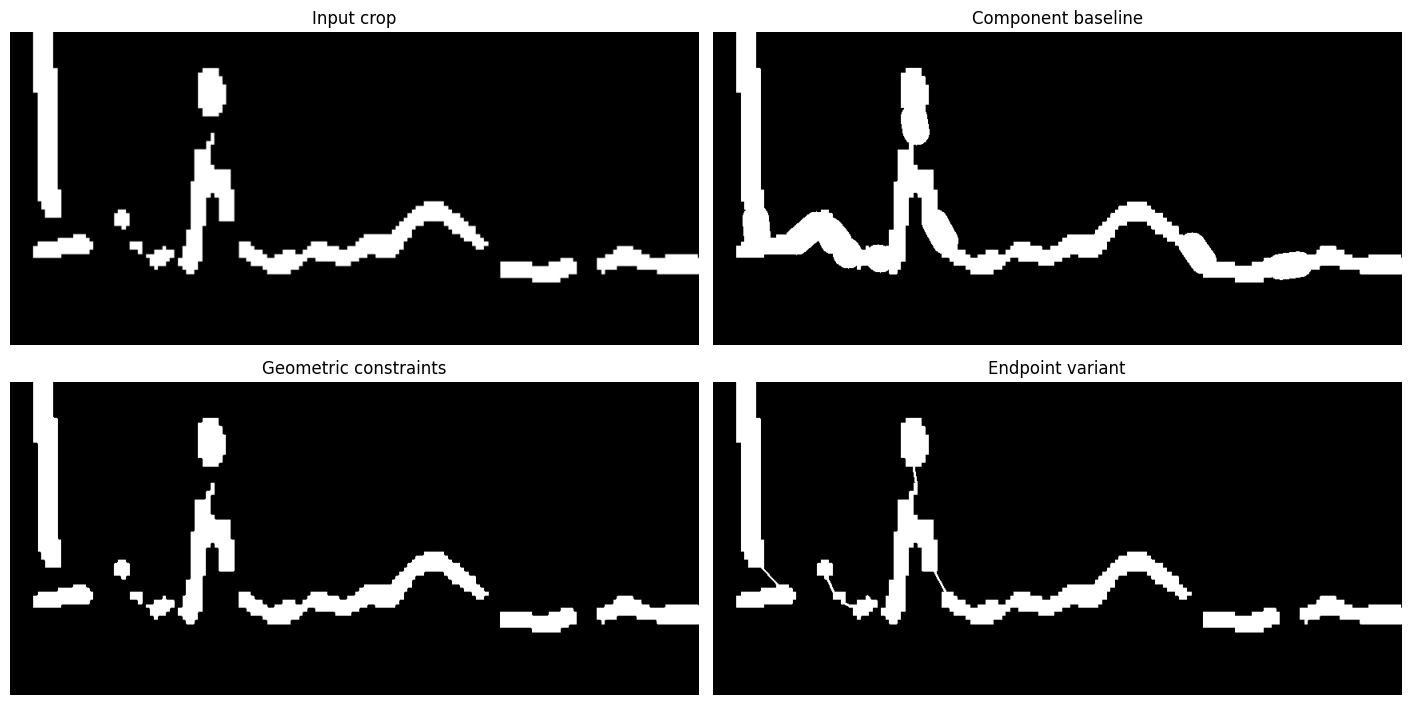

In [5]:
import matplotlib.pyplot as plt

panels = [
    (INPUT_IMAGE, "Input crop"),
    (OUTPUT_DIR / "component-bridged.png", "Component baseline"),
    (OUTPUT_DIR / "constrained-bridged.png", "Geometric constraints"),
    (OUTPUT_DIR / "endpoint-bridged.png", "Endpoint variant"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 7), constrained_layout=True)
for ax, (path, title) in zip(axes.ravel(), panels):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.show()